<a href="https://colab.research.google.com/github/EconShark/23_big_data_analysis_class/blob/main/Baitap01/BigData_PySpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CƠ SỞ PHÂN TÍCH DỮ LIỆU LỚN DÙNG PYSPARK

## Notebook thực hành
Notebook này đi cùng handout Word. Đặt notebook ở thư mục gốc của bộ tài liệu, sao cho dữ liệu nằm trong `Datasets/`.

In [1]:
!git clone --depth 1 https://github.com/EconShark/23_big_data_analysis_class.git
!cp -r 23_big_data_analysis_class/Lab03_Big_Data_Fundamentals_with_PySpark/Datasets/ ./
!rm -rf 23_big_data_analysis_class

Cloning into '23_big_data_analysis_class'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 106 (delta 10), reused 93 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 79.96 MiB | 11.60 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (89/89), done.


> **Lưu ý:** Nếu máy chưa cài PySpark, có thể chạy ô cài đặt bên dưới một lần. Trên Google Colab, thường cần cài `pyspark`.

In [ ]:
# Bỏ dấu # nếu cần cài đặt
# !pip install -q pyspark

# BÀI 1 - LÀM QUEN VỚI APACHE SPARK VÀ PYSPARK

## Bài 1.1. Khởi tạo Spark

In [2]:
from pathlib import Path
import sys, re, string

#DATA_DIR = Path('Datasets')
#print('Data dir exists:', DATA_DIR.exists())

from pyspark.sql import SparkSession, functions as F
spark = (SparkSession.builder
         .appName('BigDataFundamentals')
         .master('local[*]')
         .getOrCreate())
sc = spark.sparkContext

In [3]:


print('1. In phiên bản Spark/ Spark version:', spark.version)
print('2. In Python version/Python:', sys.version.split()[0])
print('3. In master/ Master:', sc.master)
print('4. Xác định số core Spark có thể sử dụng/ Default parallelism:', sc.defaultParallelism)
print('5. In tên ứng dụng hiện tại/ App name:', sc.appName)

1. In phiên bản Spark/ Spark version: 4.0.4
2. In Python version/Python: 3.13.16
3. In master/ Master: local[*]
4. Xác định số core Spark có thể sử dụng/ Default parallelism: 2
5. In tên ứng dụng hiện tại/ App name: BigDataFundamentals


## Bài 1.2. Parallel Collection

6. Chuyển danh sách thành RDD.
7. Đếm số phần tử.
8. Hiển thị 10 phần tử đầu tiên.
9. Tính tổng từ 1 đến 100.
10. Tìm số lớn nhất và nhỏ nhất.

In [4]:
numbers = list(range(1, 101))

print("\n6. Chuyển danh sách thành RDD.")
numbers_rdd = sc.parallelize(numbers)

print('\n7. Đếm số phần tử./ Count:', numbers_rdd.count())
print('\n8. Hiển thị 10 phần tử đầu tiên./ First 10:', numbers_rdd.take(10))
print('\n9. Tính tổng từ 1 đến 100./ Sum:', numbers_rdd.sum())
print('\n10. Tìm số lớn nhất và nhỏ nhất./ Min:', numbers_rdd.min(), 'Max:', numbers_rdd.max())


6. Chuyển danh sách thành RDD.

7. Đếm số phần tử./ Count: 100

8. Hiển thị 10 phần tử đầu tiên./ First 10: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

9. Tính tổng từ 1 đến 100./ Sum: 5050

10. Tìm số lớn nhất và nhỏ nhất./ Min: 1 Max: 100


## Bài 1.3. Map và Filter

11. Tạo RDD chứa bình phương của mỗi phần tử.
12. Lấy các số chia hết cho 3.
13. Lấy các số chia hết cho 5.
14. Lấy các số chia hết cho cả 3 và 5.
Câu hỏi: Giải thích sự khác nhau giữa rdd.map(...) và hàm map(...) của Python.

Câu hỏi: Giải thích sự khác nhau giữa rdd.map(...) và hàm map(...) của Python.

In [ ]:
# TODO: Sinh viên hoàn thiện
squares = numbers_rdd.map(lambda x: x**2)
div3 = numbers_rdd.filter(lambda x: x % 3 == 0)
div5 = numbers_rdd.filter(lambda x: x % 5 == 0)
div15 = numbers_rdd.filter(lambda x: x % 15 == 0)
print(squares.take(10))
print(div3.take(10))
print(div5.take(10))
print(div15.collect())

[1, 4, 9, 16, 25, 36, 49, 64, 81, 100]
[3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
[5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
[15, 30, 45, 60, 75, 90]


In [ ]:
rdd = sc.parallelize(range(1, 1_000_000))
result = rdd.filter(lambda x: x % 2 == 0).map(lambda x: x * x)
# Transformation chưa buộc Spark tính toán ngay.
result.take(10)

[4, 16, 36, 64, 100, 144, 196, 256, 324, 400]

**Câu hỏi:** `filter`, `map`, `take` thuộc loại nào? Vì sao Spark dùng lazy evaluation?

# BÀI 2. Xử lý văn bản với RDD

## 2.1 Đọc Complete Shakespeare

In [ ]:
shakespeare_path = DATA_DIR / 'Complete Shakespeare.txt'
text_rdd = sc.textFile(str(shakespeare_path))
print('Lines:', text_rdd.count())
print('Partitions:', text_rdd.getNumPartitions())
for line in text_rdd.take(5):
    print(line)

Lines: 18014
Partitions: 2
The Project Gutenberg EBook of The Complete Works of William Shakespeare, by
William Shakespeare

This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever.  You may copy it, give it away or


## 2.2 Word Count cơ bản

In [ ]:
words = text_rdd.flatMap(lambda line: line.split())
word_counts = (words
               .map(lambda w: (w, 1))
               .reduceByKey(lambda a, b: a + b))
word_counts.take(10)

[('Gutenberg', 7),
 ('EBook', 1),
 ('of', 2060),
 ('Complete', 3),
 ('Works', 3),
 ('by', 413),
 ('Shakespeare', 12),
 ('eBook', 2),
 ('for', 841),
 ('use', 38)]

In [ ]:
top20_raw = word_counts.takeOrdered(20, key=lambda x: -x[1])
top20_raw

[('the', 3109),
 ('I', 2888),
 ('and', 2403),
 ('to', 2295),
 ('of', 2060),
 ('a', 1643),
 ('my', 1531),
 ('you', 1495),
 ('in', 1434),
 ('that', 1221),
 ('is', 1119),
 ('not', 1030),
 ('with', 923),
 ('And', 907),
 ('his', 867),
 ('for', 841),
 ('your', 835),
 ('have', 805),
 ('be', 804),
 ('me', 776)]

## 2.3 Làm sạch văn bản

In [ ]:
stopwords = set(['the','and','of','to','a','in','that','is','it','for','as','with','his','he','be','this','not','but','you'])

def clean_line(line):
    line = line.lower()
    line = re.sub(r'[^a-z\s]', ' ', line)
    return [w for w in line.split() if len(w) >= 3 and w not in stopwords]

clean_words = text_rdd.flatMap(clean_line)
clean_counts = clean_words.map(lambda w: (w, 1)).reduceByKey(lambda a,b: a+b)
clean_counts.takeOrdered(20, key=lambda x: -x[1])

[('your', 978),
 ('have', 914),
 ('thou', 822),
 ('him', 815),
 ('will', 691),
 ('what', 656),
 ('thy', 650),
 ('all', 582),
 ('are', 571),
 ('her', 556),
 ('thee', 522),
 ('shall', 481),
 ('love', 458),
 ('which', 453),
 ('our', 422),
 ('sir', 414),
 ('they', 405),
 ('good', 401),
 ('from', 398),
 ('when', 387)]

## 2.4 Phân tích chiều dài từ

In [ ]:
length_groups = (clean_words
    .map(lambda w: ('1-4' if len(w) <= 4 else '5-8' if len(w) <= 8 else '>=9', 1))
    .reduceByKey(lambda a,b: a+b)
    .collectAsMap())
length_groups

{'5-8': 39316, '>=9': 5031, '1-4': 38746}

## 2.5 Bài tập mở rộng
- So sánh `groupByKey()` và `reduceByKey()`.
- Thử `distinct()`, `sortByKey()`, `repartition()` và `coalesce()`.

In [ ]:
# TODO: thử các transformation nâng cao tại đây

# BÀI 3. DataFrame và Spark SQL với FIFA 2018

## 3.1 Đọc dữ liệu

In [ ]:
fifa_path = DATA_DIR / 'Fifa2018_dataset.csv'
df = (spark.read
      .option('header', True)
      .option('inferSchema', True)
      .csv(str(fifa_path)))
print('Rows:', df.count())
print('Columns:', len(df.columns))
df.printSchema()
df.show(5, truncate=False)

Rows: 17981
Columns: 75
root
 |-- _c0: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Photo: string (nullable = true)
 |-- Nationality: string (nullable = true)
 |-- Flag: string (nullable = true)
 |-- Overall: integer (nullable = true)
 |-- Potential: integer (nullable = true)
 |-- Club: string (nullable = true)
 |-- Club Logo: string (nullable = true)
 |-- Value: string (nullable = true)
 |-- Wage: string (nullable = true)
 |-- Special: integer (nullable = true)
 |-- Acceleration: string (nullable = true)
 |-- Aggression: string (nullable = true)
 |-- Agility: string (nullable = true)
 |-- Balance: string (nullable = true)
 |-- Ball control: string (nullable = true)
 |-- Composure: string (nullable = true)
 |-- Crossing: string (nullable = true)
 |-- Curve: string (nullable = true)
 |-- Dribbling: string (nullable = true)
 |-- Finishing: string (nullable = true)
 |-- Free kick accuracy: string (nullable = true)
 |-- GK diving: s

## 3.2 Missing values

In [ ]:
missing_exprs = [F.sum(F.col(c).isNull().cast('int')).alias(c) for c in df.columns]
missing = df.select(missing_exprs)
missing.show(truncate=False)

+---+----+---+-----+-----------+----+-------+---------+----+---------+-----+----+-------+------------+----------+-------+-------+------------+---------+--------+-----+---------+---------+------------------+---------+-----------+----------+--------------+-----------+----------------+-------------+-------+------------+----------+-------+---------+-----------+---------+-------------+----------+--------------+------------+-------+---------------+--------+------+-------+----+----+----+----+----+---+----+----+----+----+----+----+----+----+----+----+-------------------+----+----+----+----+----+----+----+----+----+----+----+
|_c0|Name|Age|Photo|Nationality|Flag|Overall|Potential|Club|Club Logo|Value|Wage|Special|Acceleration|Aggression|Agility|Balance|Ball control|Composure|Crossing|Curve|Dribbling|Finishing|Free kick accuracy|GK diving|GK handling|GK kicking|GK positioning|GK reflexes|Heading accuracy|Interceptions|Jumping|Long passing|Long shots|Marking|Penalties|Positioning|Reactions|Short 

## 3.3 Xác định các cột quan trọng

In [ ]:
print(df.columns)
# Một số phiên bản dataset có tên cột khác nhau.
# Chọn các cột tồn tại trong danh sách mong muốn:
wanted = ['Name','Age','Nationality','Overall','Potential','Club']
selected = [c for c in wanted if c in df.columns]
print('Selected columns:', selected)
df.select(*selected).show(10, truncate=False)

['_c0', 'Name', 'Age', 'Photo', 'Nationality', 'Flag', 'Overall', 'Potential', 'Club', 'Club Logo', 'Value', 'Wage', 'Special', 'Acceleration', 'Aggression', 'Agility', 'Balance', 'Ball control', 'Composure', 'Crossing', 'Curve', 'Dribbling', 'Finishing', 'Free kick accuracy', 'GK diving', 'GK handling', 'GK kicking', 'GK positioning', 'GK reflexes', 'Heading accuracy', 'Interceptions', 'Jumping', 'Long passing', 'Long shots', 'Marking', 'Penalties', 'Positioning', 'Reactions', 'Short passing', 'Shot power', 'Sliding tackle', 'Sprint speed', 'Stamina', 'Standing tackle', 'Strength', 'Vision', 'Volleys', 'CAM', 'CB', 'CDM', 'CF', 'CM', 'ID', 'LAM', 'LB', 'LCB', 'LCM', 'LDM', 'LF', 'LM', 'LS', 'LW', 'LWB', 'Preferred Positions', 'RAM', 'RB', 'RCB', 'RCM', 'RDM', 'RF', 'RM', 'RS', 'RW', 'RWB', 'ST']
Selected columns: ['Name', 'Age', 'Nationality', 'Overall', 'Potential', 'Club']
+-----------------+---+-----------+-------+---------+-------------------+
|Name             |Age|Nationality|Ov

## 3.4 Filter và OrderBy

In [ ]:
# Các ô dưới đây chỉ chạy khi dataset có các cột tương ứng.
if 'Overall' in df.columns:
    df.filter(F.col('Overall') > 85).orderBy(F.desc('Overall')).show(20, truncate=False)
if {'Age','Potential'}.issubset(df.columns):
    df.filter(F.col('Age') < 21).orderBy(F.desc('Potential')).show(10, truncate=False)

+---+-----------------+---+-----------------------------------------------+-----------+-----------------------------------+-------+---------+-------------------+------------------------------------------+------+-----+-------+------------+----------+-------+-------+------------+---------+--------+-----+---------+---------+------------------+---------+-----------+----------+--------------+-----------+----------------+-------------+-------+------------+----------+-------+---------+-----------+---------+-------------+----------+--------------+------------+-------+---------------+--------+------+-------+----+----+----+----+----+------+----+----+----+----+----+----+----+----+----+----+-------------------+----+----+----+----+----+----+----+----+----+----+----+
|_c0|Name             |Age|Photo                                          |Nationality|Flag                               |Overall|Potential|Club               |Club Logo                                 |Value |Wage |Special|Acceleratio

## 3.5 GroupBy và Aggregate

In [ ]:
if 'Nationality' in df.columns:
    df.groupBy('Nationality').count().orderBy(F.desc('count')).show(10, truncate=False)

if {'Nationality','Overall','Potential','Age'}.issubset(df.columns):
    (df.groupBy('Nationality')
       .agg(F.avg('Overall').alias('avg_overall'),
            F.avg('Potential').alias('avg_potential'),
            F.avg('Age').alias('avg_age'),
            F.count('*').alias('n'))
       .orderBy(F.desc('avg_overall'))
       .show(20, truncate=False))

+-----------+-----+
|Nationality|count|
+-----------+-----+
|England    |1630 |
|Germany    |1140 |
|Spain      |1019 |
|France     |978  |
|Argentina  |965  |
|Brazil     |812  |
|Italy      |799  |
|Colombia   |592  |
|Japan      |469  |
|Netherlands|429  |
+-----------+-----+
only showing top 10 rows
+--------------+-----------------+-----------------+------------------+----+
|Nationality   |avg_overall      |avg_potential    |avg_age           |n   |
+--------------+-----------------+-----------------+------------------+----+
|Cuba          |73.0             |75.5             |27.5              |2   |
|Oman          |73.0             |73.0             |35.0              |1   |
|Syria         |72.5             |75.5             |26.333333333333332|6   |
|Mozambique    |72.33333333333333|75.66666666666667|26.333333333333332|3   |
|Guatemala     |72.0             |72.0             |31.0              |1   |
|Israel        |71.16666666666667|72.83333333333333|26.833333333333332|12  |
|E

## 3.6 Phân tích câu lạc bộ

In [ ]:
if {'Club','Overall','Potential','Age'}.issubset(df.columns):
    club_stats = (df.groupBy('Club')
        .agg(F.count('*').alias('players'),
             F.avg('Overall').alias('avg_overall'),
             F.avg('Potential').alias('avg_potential'),
             F.avg('Age').alias('avg_age')))
    club_stats.orderBy(F.desc('players')).show(10, truncate=False)

+------------------+-------+-----------------+-----------------+------------------+
|Club              |players|avg_overall      |avg_potential    |avg_age           |
+------------------+-------+-----------------+-----------------+------------------+
|NULL              |248    |67.33467741935483|69.6774193548387 |27.657258064516128|
|Villarreal CF     |35     |73.62857142857143|79.14285714285714|24.742857142857144|
|Manchester United |34     |77.70588235294117|83.23529411764706|24.61764705882353 |
|UD Las Palmas     |34     |72.41176470588235|76.52941176470588|25.529411764705884|
|Olympique Lyonnais|34     |70.70588235294117|78.73529411764706|22.323529411764707|
|VfL Wolfsburg     |34     |71.76470588235294|79.26470588235294|23.176470588235293|
|OGC Nice          |34     |71.91176470588235|79.6470588235294 |23.08823529411765 |
|FC Nantes         |34     |70.17647058823529|75.1470588235294 |23.647058823529413|
|Borussia Dortmund |34     |75.70588235294117|81.70588235294117|24.294117647

## 3.7 Spark SQL

In [ ]:
df.createOrReplaceTempView('fifa')
spark.sql('SELECT * FROM fifa LIMIT 10').show(truncate=False)

+---+-----------------+---+-----------------------------------------------+-----------+-----------------------------------+-------+---------+-------------------+------------------------------------------+------+-----+-------+------------+----------+-------+-------+------------+---------+--------+-----+---------+---------+------------------+---------+-----------+----------+--------------+-----------+----------------+-------------+-------+------------+----------+-------+---------+-----------+---------+-------------+----------+--------------+------------+-------+---------------+--------+------+-------+----+----+----+----+----+------+----+----+----+----+----+----+----+----+----+----+-------------------+----+----+----+----+----+----+----+----+----+----+----+
|_c0|Name             |Age|Photo                                          |Nationality|Flag                               |Overall|Potential|Club               |Club Logo                                 |Value |Wage |Special|Acceleratio

In [ ]:
# Ví dụ động: chỉ chạy nếu cột tồn tại
if 'Overall' in df.columns:
    spark.sql('SELECT * FROM fifa ORDER BY Overall DESC LIMIT 10').show(truncate=False)
if {'Nationality','Overall'}.issubset(df.columns):
    spark.sql('''
        SELECT Nationality, AVG(Overall) AS avg_overall, COUNT(*) AS n
        FROM fifa
        GROUP BY Nationality
        ORDER BY avg_overall DESC
        LIMIT 10
    ''').show(truncate=False)

+---+-----------------+---+-----------------------------------------------+-----------+-----------------------------------+-------+---------+-------------------+------------------------------------------+------+-----+-------+------------+----------+-------+-------+------------+---------+--------+-----+---------+---------+------------------+---------+-----------+----------+--------------+-----------+----------------+-------------+-------+------------+----------+-------+---------+-----------+---------+-------------+----------+--------------+------------+-------+---------------+--------+------+-------+----+----+----+----+----+------+----+----+----+----+----+----+----+----+----+----+-------------------+----+----+----+----+----+----+----+----+----+----+----+
|_c0|Name             |Age|Photo                                          |Nationality|Flag                               |Overall|Potential|Club               |Club Logo                                 |Value |Wage |Special|Acceleratio

### Bài tập Spark SQL
1. Viết truy vấn tìm cầu thủ `Age < 21` và `Potential >= 85`.
2. Tìm 10 quốc gia có nhiều cầu thủ nhất.
3. So sánh kết quả với DataFrame API.

In [ ]:
# TODO: viết truy vấn SQL ở đây

# BÀI 4. Machine Learning với PySpark

## 4A. K-Means trên 5000_points.txt

In [ ]:
points_path = DATA_DIR / '5000_points.txt'
# Tập này thường là 2 cột số, phân tách bởi khoảng trắng/tab.
raw_points = spark.read.text(str(points_path))
points = (raw_points
    .select(F.split(F.trim('value'), r'\s+').alias('v'))
    .filter(F.size('v') >= 2)
    .select(F.col('v')[0].cast('double').alias('x'),
            F.col('v')[1].cast('double').alias('y'))
    .na.drop())
points.show(5)
print('Rows:', points.count())

+--------+--------+
|       x|       y|
+--------+--------+
|664159.0|550946.0|
|665845.0|557965.0|
|597173.0|575538.0|
|618600.0|551446.0|
|635690.0|608046.0|
+--------+--------+
only showing top 5 rows
Rows: 5000


In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

assembler = VectorAssembler(inputCols=['x','y'], outputCol='features')
points_vec = assembler.transform(points)
evaluator = ClusteringEvaluator(featuresCol='features', predictionCol='prediction', metricName='silhouette')

results = []
for k in range(2, 21):
    model = KMeans(k=k, seed=42, featuresCol='features').fit(points_vec)
    pred = model.transform(points_vec)
    score = evaluator.evaluate(pred)
    results.append((k, score))
results

[(2, 0.5404887919301121),
 (3, 0.5793336179593067),
 (4, 0.614662491276157),
 (5, 0.6168889543794707),
 (6, 0.6454923995296126),
 (7, 0.6519360091992706),
 (8, 0.6807838059882749),
 (9, 0.6834164572792013),
 (10, 0.7460311550351746),
 (11, 0.7158019381588918),
 (12, 0.7979746364419855),
 (13, 0.8151545885248006),
 (14, 0.7876235718280287),
 (15, 0.7922061421032397),
 (16, 0.7538433657875201),
 (17, 0.7772139043859905),
 (18, 0.7539670487459043),
 (19, 0.7899754272597316),
 (20, 0.75655192007236)]

In [ ]:
best_k, best_score = max(results, key=lambda x: x[1])
print('Best k:', best_k, 'Silhouette:', best_score)
best_model = KMeans(k=best_k, seed=42, featuresCol='features').fit(points_vec)
predictions = best_model.transform(points_vec)

Best k: 13 Silhouette: 0.8151545885248006


### Trực quan hóa
Chỉ chuyển số lượng dữ liệu cần vẽ sang Pandas. Với Big Data thật, nên `sample()` hoặc `limit()` trước `toPandas()`.

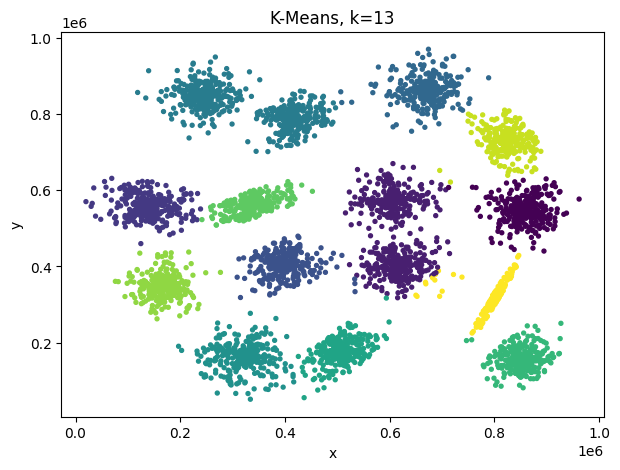

In [ ]:
import matplotlib.pyplot as plt
plot_df = predictions.select('x','y','prediction').limit(10000).toPandas()
plt.figure(figsize=(7,5))
plt.scatter(plot_df['x'], plot_df['y'], c=plot_df['prediction'], s=8)
plt.xlabel('x'); plt.ylabel('y'); plt.title(f'K-Means, k={best_k}')
plt.show()

## 4B. Phân loại Spam/Ham

In [ ]:
spam_rdd = sc.textFile(str(DATA_DIR / 'spam.txt')).map(lambda x: (x, 1.0))
ham_rdd  = sc.textFile(str(DATA_DIR / 'ham.txt')).map(lambda x: (x, 0.0))
text_df = spark.createDataFrame(spam_rdd.union(ham_rdd), ['text','label'])
text_df.groupBy('label').count().show()
text_df.show(5, truncate=80)

+-----+-----+
|label|count|
+-----+-----+
|  1.0|  747|
|  0.0| 4827|
+-----+-----+

+--------------------------------------------------------------------------------+-----+
|                                                                            text|label|
+--------------------------------------------------------------------------------+-----+
|                                You have 1 new message. Please call 08712400200.|  1.0|
|Urgent! Please call 09061743811 from landline. Your ABTA complimentary 4* Ten...|  1.0|
|Dear 0776xxxxxxx U've been invited to XCHAT. This is our final attempt to con...|  1.0|
|U 447801259231 have a secret admirer who is looking 2 make contact with U-fin...|  1.0|
|Congrats! 2 mobile 3G Videophones R yours. call 09061744553 now! videochat wi...|  1.0|
+--------------------------------------------------------------------------------+-----+
only showing top 5 rows


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

train_df, test_df = text_df.randomSplit([0.8, 0.2], seed=42)

tokenizer = Tokenizer(inputCol='text', outputCol='tokens')
remover = StopWordsRemover(inputCol='tokens', outputCol='filtered')
hashing = HashingTF(inputCol='filtered', outputCol='tf', numFeatures=1<<14)
idf = IDF(inputCol='tf', outputCol='features')
lr = LogisticRegression(featuresCol='features', labelCol='label', maxIter=50)

pipeline = Pipeline(stages=[tokenizer, remover, hashing, idf, lr])
model = pipeline.fit(train_df)
pred = model.transform(test_df)
pred.select('text','label','prediction','probability').show(10, truncate=70)

+----------------------------------------------------------------------+-----+----------+-------------------------------------------+
|                                                                  text|label|prediction|                                probability|
+----------------------------------------------------------------------+-----+----------+-------------------------------------------+
|+123 Congratulations - in this week's competition draw u have won t...|  1.0|       1.0|               [3.6852342518117776E-33,1.0]|
|07732584351 - Rodger Burns - MSG = We tried to call you re your rep...|  1.0|       1.0|[1.8543192758730684E-14,0.9999999999999815]|
|1000's of girls many local 2 u who r virgins 2 this & r ready 2 4fi...|  1.0|       0.0|    [0.99999999331762,6.682379982692055E-9]|
|44 7732584351, Do you want a New Nokia 3510i colour phone Delivered...|  1.0|       1.0|[1.1431904371173692E-14,0.9999999999999886]|
|500 New Mobiles from 2004, MUST GO! Txt: NOKIA to No: 89545 &

In [ ]:
acc_eval = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
f1_eval  = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1')
prec_eval = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision')
rec_eval = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall')
auc_eval = BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC')

print('Accuracy :', acc_eval.evaluate(pred))
print('Precision:', prec_eval.evaluate(pred))
print('Recall   :', rec_eval.evaluate(pred))
print('F1       :', f1_eval.evaluate(pred))
print('ROC-AUC  :', auc_eval.evaluate(pred))

Accuracy : 0.9712430426716141
Precision: 0.9711508170526056
Recall   : 0.9712430426716141
F1       : 0.9711951068980964
ROC-AUC  : 0.9755111976630974


**Câu hỏi:** Accuracy có luôn là metric tốt nhất cho phát hiện spam không? Khi dữ liệu mất cân bằng nên quan tâm thêm những metric nào?

# BÀI 5. Bài tập bổ sung với people.csv và Movie ratings.csv

## 5.1 people.csv

In [ ]:
people_path = DATA_DIR / 'people.csv'
people = spark.read.option('header', True).option('inferSchema', True).csv(str(people_path))
people.show()
people.printSchema()

+---+---------+-----------------+------+-------------------+
|_c0|person_id|             name|   sex|      date of birth|
+---+---------+-----------------+------+-------------------+
|  0|      100|   Penelope Lewis|female|1990-08-31 00:00:00|
|  1|      101|    David Anthony|  male|1971-10-14 00:00:00|
|  2|      102|        Ida Shipp|female|1962-05-24 00:00:00|
|  3|      103|     Joanna Moore|female|2017-03-10 00:00:00|
|  4|      104|   Lisandra Ortiz|female|2020-08-05 00:00:00|
|  5|      105|    David Simmons|  male|1999-12-30 00:00:00|
|  6|      106|    Edward Hudson|  male|1983-05-09 00:00:00|
|  7|      107|     Albert Jones|  male|1990-09-13 00:00:00|
|  8|      108| Leonard Cavender|  male|1958-08-08 00:00:00|
|  9|      109|   Everett Vadala|  male|2005-05-24 00:00:00|
| 10|      110| Freddie Claridge|  male|2002-05-07 00:00:00|
| 11|      111|Annabelle Rosseau|female|1989-07-13 00:00:00|
| 12|      112|    Eulah Emanuel|female|1976-01-19 00:00:00|
| 13|      113|       Sh

**Yêu cầu:** tự đặt ít nhất 3 câu hỏi phân tích phù hợp với các cột thực tế của `people.csv`.

## 5.2 Movie ratings.csv

In [ ]:
ratings_path = DATA_DIR / 'Movie ratings.csv'
ratings = spark.read.option('header', True).option('inferSchema', True).csv(str(ratings_path))
ratings.show(5, truncate=False)
ratings.printSchema()

+---+----+---+----------+
|1  |31  |2.5|1260759144|
+---+----+---+----------+
|1  |1029|3.0|1260759179|
|1  |1061|3.0|1260759182|
|1  |1129|2.0|1260759185|
|1  |1172|4.0|1260759205|
|1  |1263|2.0|1260759151|
+---+----+---+----------+
only showing top 5 rows
root
 |-- 1: integer (nullable = true)
 |-- 31: integer (nullable = true)
 |-- 2.5: double (nullable = true)
 |-- 1260759144: integer (nullable = true)



**Yêu cầu:**
- Kiểm tra schema và missing values.
- Tìm nhóm/phim/người dùng có số lượng rating lớn nhất tùy theo cấu trúc file.
- Tính rating trung bình theo một chiều dữ liệu phù hợp.
- Viết ít nhất 2 truy vấn Spark SQL.

# BÀI MỞ RỘNG

Chọn dataset tối thiểu **100.000 dòng**, thực hiện:
1. Data Understanding.
2. Data Cleaning.
3. Ít nhất 6 thao tác DataFrame.
4. Ít nhất 5 truy vấn Spark SQL.
5. Ít nhất 5 câu hỏi phân tích.
6. Một mô hình ML bằng `pyspark.ml`.
7. Kết luận và hạn chế.

## Checklist nộp bài
- [ ] Notebook chạy từ đầu đến cuối.
- [ ] Không dùng `collect()`/`toPandas()` cho toàn bộ Big Data.
- [ ] Có giải thích kết quả, không chỉ có code.
- [ ] Có Spark SQL và DataFrame API.
- [ ] Có ít nhất một mô hình ML.
- [ ] Có phần kết luận.

## Câu hỏi kiểm tra cuối bài
1. Apache Spark khác Pandas ở điểm nào?
2. RDD là gì?
3. DataFrame khác RDD như thế nào?
4. Partition dùng để làm gì?
5. Transformation là gì?
6. Action là gì?
7. Lazy Evaluation là gì?
8. map() và flatMap() khác nhau thế nào?
9. reduceByKey() khác groupByKey() thế nào?
10. Spark SQL có ưu điểm gì?
11. Tại sao không nên dùng collect() với dữ liệu rất lớn?